# Thực hành Buổi 07: Feature Engineering & RFM Customer Analytics

**Khóa đào tạo:** Phân tích Dữ liệu Lớn (Big Data Analysis)

**Công cụ:** Pandas, NumPy, Scikit-Learn

**Đầu vào ➔ Đầu ra:** `customer_churn.csv` + dataset sạch của Bài 6 ➔ Feature Matrix sẵn sàng cho Machine Learning (`data/processed/feature_matrix.parquet`)

> **Chuỗi bài 06–09** là một pipeline liên tục: Bài 6 làm sạch ➔ Bài 7 tạo đặc trưng ➔ Bài 8 báo cáo KPI ➔ Bài 9 chẩn đoán & phát hiện bất thường. Chạy các cell theo đúng thứ tự từ trên xuống.
> ⚠️ **Điều kiện tiên quyết:** chạy xong `lab6/Lab6.ipynb` trước — buổi này đọc `data/processed/enterprise_transactions_clean.parquet` và `data/raw/customer_churn.csv` do Bài 6 sinh ra.

In [40]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
pd.options.display.float_format = "{:,.2f}".format

RAW = Path("../data/raw"); RAW.mkdir(parents=True, exist_ok=True)
PROCESSED = Path("../data/processed"); PROCESSED.mkdir(parents=True, exist_ok=True)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 2.2.2 | numpy 1.26.4


# BÀI 7 — FEATURE ENGINEERING & RFM CUSTOMER ANALYTICS

**Mục tiêu:** từ dữ liệu giao dịch sạch (Bài 6) + hồ sơ `customer_churn.csv`, xây dựng **Feature Matrix cấp khách hàng sẵn sàng cho Machine Learning**, với trung tâm là bộ chỉ số **RFM**:

| Chỉ số | Nghĩa | Cách tính |
|:---|:---|:---|
| **R — Recency** | mua gần đây chưa? | số ngày từ lần mua cuối đến mốc phân tích |
| **F — Frequency** | mua thường xuyên không? | tổng số giao dịch |
| **M — Monetary** | chi bao nhiêu tiền? | tổng giá trị giao dịch |

## 7.1. Nạp dữ liệu

In [41]:
tx = pd.read_parquet(PROCESSED / "enterprise_transactions_clean.parquet")
kh = pd.read_csv(RAW / "customer_churn.csv")
# Chỉ tính hành vi mua trên giao dịch hoàn tất
tx_ht = tx[tx["status"] == "HOAN_TAT"].copy()
tx_ht.head()

,transaction_id,ts,customer_id,branch,channel,category,quantity,unit_price,amount,cost,payment_method,status,is_fraud,amount_da_impute,cost_da_impute,la_outlier_iqr
0,T0000008,2025-01-01 03:22:34,C05726,Hải Phòng,Online,Thời trang,1.00,"11,563,302.93","11,563,302.93","8,094,312.05",VI_DIEN_TU,HOAN_TAT,1,True,False,True
1,T0000001,2025-01-01 07:02:09,C05154,TP HCM,Online,Thực phẩm,3.00,"183,000.00","549,000.00","457,912.53",THE,HOAN_TAT,0,False,False,False
2,T0000002,2025-01-01 07:13:12,C04651,Đà Nẵng,Cửa hàng,Thực phẩm,2.00,"158,000.00","316,000.00","196,960.82",THE,HOAN_TAT,0,False,False,False
3,T0000003,2025-01-01 07:22:42,C02675,Cần Thơ,Cửa hàng,Mỹ phẩm,1.00,"515,000.00","515,000.00","361,470.72",VI_DIEN_TU,HOAN_TAT,0,False,False,False
4,T0000004,2025-01-01 07:29:24,C02456,TP HCM,Online,Điện tử,2.00,"1,031,000.00","1,752,700.00","1,268,568.43",THE,HOAN_TAT,0,False,True,False


In [42]:
print(f"Giao dịch hoàn tất: {len(tx_ht):,} | Khách hàng trong hồ sơ: {len(kh):,}")
kh.head()

Giao dịch hoàn tất: 57,882 | Khách hàng trong hồ sơ: 8,000


,customer_id,age,gender,city,tenure_months,support_tickets,churn
0,C00001,47,Nữ,Hà Nội,15,1,0
1,C00002,32,Nam,Đà Nẵng,20,2,0
2,C00003,38,Nam,Cần Thơ,54,1,0
3,C00004,60,Nam,TP HCM,37,2,0
4,C00005,23,Nữ,TP HCM,39,0,0


## 7.2. Biến đổi đặc trưng ở cấp giao dịch

Hai biến đổi kinh điển trước khi tổng hợp:
- **Đặc trưng thời gian** rút từ `ts`: giờ, thứ, tháng, cờ cuối tuần — mô hình không đọc được timestamp thô.
- **Biến đổi log** cho biến tiền tệ lệch phải: `log1p` kéo phân phối về gần chuẩn, giúp thuật toán dựa trên khoảng cách hoạt động tốt hơn.

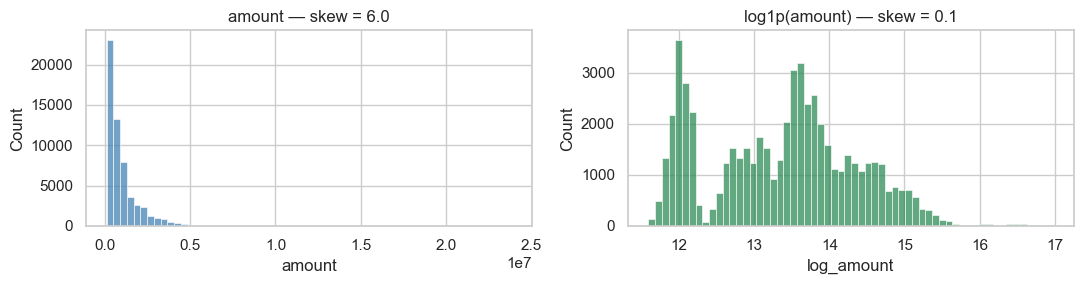

In [43]:
tx_ht["gio"] = tx_ht["ts"].dt.hour
tx_ht["thu"] = tx_ht["ts"].dt.dayofweek          # 0=Thứ 2 ... 6=Chủ nhật
tx_ht["thang"] = tx_ht["ts"].dt.to_period("M").astype(str)
tx_ht["cuoi_tuan"] = (tx_ht["thu"] >= 5).astype(int)
tx_ht["log_amount"] = np.log1p(tx_ht["amount"])

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
sns.histplot(tx_ht["amount"], bins=60, ax=axes[0], color="steelblue")
axes[0].set_title(f"amount — skew = {tx_ht['amount'].skew():.1f}")
sns.histplot(tx_ht["log_amount"], bins=60, ax=axes[1], color="seagreen")
axes[1].set_title(f"log1p(amount) — skew = {tx_ht['log_amount'].skew():.1f}")
plt.tight_layout(); plt.show()

## 7.3. Tính bảng RFM

Mốc phân tích (snapshot) = ngày cuối cùng trong dữ liệu + 1 ngày. Một lệnh `groupby().agg()` duy nhất tính cả ba chỉ số:

In [44]:
# Lấy ra thời điểm giao dịch lớn nhất (muộn nhất) có trong cột 'ts'
ngay_cuoi_cung = tx_ht["ts"].max()

# Cộng thêm 1 ngày để làm mốc quy chiếu tính toán (giống như ngày "hôm nay" của hệ thống)
moc = ngay_cuoi_cung + pd.Timedelta(days=1)

print("Ngày cuối cùng giao dịch:", ngay_cuoi_cung)
print("Mốc phân tích:", moc)

Ngày cuối cùng giao dịch: 2025-11-09 07:01:49
Mốc phân tích: 2025-11-10 07:01:49


In [45]:
#Thay vì để dữ liệu rải rác mỗi khách hàng mua hàng chục dòng giao dịch khác nhau, 
# ta dùng lệnh groupby("customer_id") để gom tất cả các giao dịch của cùng một người về chung một nhóm (một giỏ).
# Tạo ra đối tượng gom nhóm theo mã khách hàng
nhom_khach_hang = tx_ht.groupby("customer_id")

print(f"Tổng số khách hàng có phát sinh giao dịch: {nhom_khach_hang.ngroup().nunique():,}")

Tổng số khách hàng có phát sinh giao dịch: 7,858


In [46]:
# Tính Recency cho từng khách hàng
#Chúng ta duyệt qua từng khách hàng, tìm ra ngày mua hàng lớn nhất (s.max()) của họ, 
# rồi lấy mốc phân tích trừ đi ngày đó để biết khách hàng đã "biến mất" bao nhiêu ngày kể từ lần mua gần nhất
recency_df = nhom_khach_hang.agg(
    recency=("ts", lambda s: (moc - s.max()).days)
)

print(recency_df.head())

             recency
customer_id         
C00001             1
C00002             1
C00003             1
C00004             1
C00005             3


In [47]:
# Tính Frequency cho từng khách hàng
#đếm tổng số lượng dòng giao dịch ("size") mà mỗi khách hàng đã thực hiện trong lịch sử.
frequency_df = nhom_khach_hang.agg(
    frequency=("transaction_id", "size")
)

print(frequency_df.head())

             frequency
customer_id           
C00001             643
C00002             439
C00003             344
C00004             306
C00005             265


In [48]:
# Tính Monetary cho từng khách hàng
#ta cộng tổng toàn bộ số tiền ("sum") từ cột amount của tất cả các giao dịch thuộc về khách hàng đó.
monetary_df = nhom_khach_hang.agg(
    monetary=("amount", "sum")
)

print(monetary_df.head())

                  monetary
customer_id               
C00001      628,184,874.65
C00002      422,404,011.00
C00003      370,743,062.76
C00004      321,978,608.44
C00005      276,176,920.00


In [49]:
import pandas as pd

# Gộp 3 bảng R, F, M lại dựa vào chỉ số chung là 'customer_id'
rfm = pd.concat([recency_df, frequency_df, monetary_df], axis=1)

rfm.head()

,recency,frequency,monetary
customer_id,,,
C00001,1,643,"628,184,874.65"
C00002,1,439,"422,404,011.00"
C00003,1,344,"370,743,062.76"
C00004,1,306,"321,978,608.44"
C00005,3,265,"276,176,920.00"


In [50]:
rfm.describe()

,recency,frequency,monetary
count,"7,858.00","7,858.00","7,858.00"
mean,60.51,7.37,"7,693,521.32"
std,61.13,14.62,"15,224,203.20"
min,1.00,1.00,"118,150.00"
25%,15.00,3.00,"2,424,287.50"
50%,40.00,5.00,"4,758,400.00"
75%,86.00,8.00,"8,499,050.00"
max,311.00,643.00,"628,184,874.65"


In [51]:
moc = tx_ht["ts"].max() + pd.Timedelta(days=1)
rfm = (tx_ht.groupby("customer_id")
       .agg(recency=("ts", lambda s: (moc - s.max()).days),
            frequency=("transaction_id", "size"),
            monetary=("amount", "sum")))
print(f"Mốc phân tích: {moc:%d/%m/%Y} | Số KH có giao dịch: {len(rfm):,}")
rfm.describe()

Mốc phân tích: 10/11/2025 | Số KH có giao dịch: 7,858


,recency,frequency,monetary
count,"7,858.00","7,858.00","7,858.00"
mean,60.51,7.37,"7,693,521.32"
std,61.13,14.62,"15,224,203.20"
min,1.00,1.00,"118,150.00"
25%,15.00,3.00,"2,424,287.50"
50%,40.00,5.00,"4,758,400.00"
75%,86.00,8.00,"8,499,050.00"
max,311.00,643.00,"628,184,874.65"


**Chấm điểm 1–5** bằng ngũ phân vị (`qcut`): điểm 5 luôn là "tốt nhất" — Recency càng NHỎ càng tốt (labels đảo), Frequency/Monetary càng LỚN càng tốt. Ghép ba điểm thành phân khúc khách hàng:

In [52]:
#Điểm R (Recency - Tính gần đây)
#Khách hàng mua hàng càng gần đây (số ngày recency càng nhỏ) thì điểm R phải càng cao (được gán nhãn 5). 
# Ngược lại, lâu lắm rồi không mua thì điểm R thấp (1). Do đó nhãn được đảo ngược thành [5, 4, 3, 2, 1]
rfm["R"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)

In [53]:
#Điểm F (Frequency - Tần suất)
#Khách hàng mua hàng càng nhiều lần (tần suất lớn) thì điểm F càng cao (từ 1 lên 5)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 5,
                   labels=[1, 2, 3, 4, 5]).astype(int)

In [54]:
#Điểm M (Monetary - Tiền tệ)
#Chi tiêu càng nhiều tiền thì điểm M càng cao (từ 1 lên 5)
rfm["M"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

In [69]:
import pandas as pd

# 1. Chấm điểm RFM từ 1-5 bằng qcut (ngũ phân vị)
# Recency: giá trị nhỏ là tốt nhất -> đảo nhãn (labels=[5, 4, 3, 2, 1])
rfm["R_score"] = pd.qcut(rfm["recency"], q=5, labels=[5, 4, 3, 2, 1])

# Frequency: giá trị lớn là tốt nhất (labels=[1, 2, 3, 4, 5])
# Lưu ý: Nếu dữ liệu có nhiều giá trị trùng lặp (duplicates), thêm duplicates='drop'
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), q=5, labels=[1, 2, 3, 4, 5])

# Monetary: giá trị lớn là tốt nhất (labels=[1, 2, 3, 4, 5])
rfm["M_score"] = pd.qcut(rfm["monetary"], q=5, labels=[1, 2, 3, 4, 5], duplicates="drop")

# Đưa các điểm số về dạng số nguyên để dễ xử lý logic
rfm[["R_score", "F_score", "M_score"]] = rfm[["R_score", "F_score", "M_score"]].astype(int)
rfm["RFM_Score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

# 2. Phân khúc khách hàng dựa trên điểm R, F, M
def segment_customer(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]
    
    # Khách VIP: Mua gần đây, tần suất cao, giá trị cao (R >= 4, F >= 4, M >= 4)
    if r >= 4 and f >= 4 and m >= 4:
        return "Khách VIP"
    
    # Khách mới: Mới mua gần đây nhưng tần suất/giá trị còn thấp (R = 5, F <= 2)
    elif r == 5 and f <= 2:
        return "Khách mới"
    
    # Khách nguy cơ rời bỏ: Từng mua tốt nhưng lâu chưa quay lại (R <= 2, F >= 3 hoặc M >= 3)
    elif r <= 2 and (f >= 3 or m >= 3):
        return "Khách nguy cơ rời bỏ"
    
    # Khách đã ngủ đông: Lâu không mua và các chỉ số đều thấp (R <= 2, F <= 2, M <= 2)
    elif r <= 2 and f <= 2 and m <= 2:
        return "Khách đã ngủ đông"
    
    # Khách trung bình: Các trường hợp còn lại ở mức cân bằng/khá
    else:
        return "Khách Trung bình"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

# Kiểm tra phân phối các phân khúc
# print(rfm["Segment"].value_counts())
rfm["phan_khuc"] = rfm["Segment"]

bang_pk = (rfm.groupby("phan_khuc")
           .agg(so_KH=("R_score", "size"), 
                R_tb=("recency", "mean"),
                F_tb=("frequency", "mean"), 
                M_tb=("monetary", "mean"))
           .sort_values("so_KH", ascending=False))

bang_pk.round(1)

,so_KH,R_tb,F_tb,M_tb
phan_khuc,,,,
Khách Trung bình,2849,29.40,5.70,"5,584,438.10"
Khách nguy cơ rời bỏ,1597,98.60,5.50,"6,610,117.00"
Khách VIP,1572,11.50,18.10,"19,406,017.70"
Khách đã ngủ đông,1535,139.60,2.30,"1,673,981.30"
Khách mới,305,6.60,2.90,"2,994,912.60"


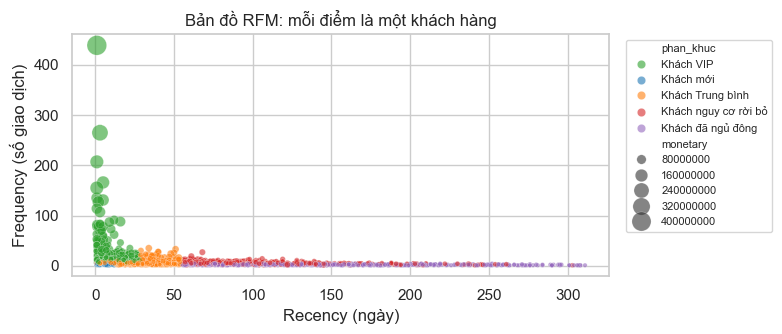

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Định nghĩa lại bảng màu chuẩn để đồng nhất với các biểu đồ trước
segment_palette = {
    "Khách VIP": "#2ca02c",          # Xanh lá
    "Khách mới": "#1f77b4",          # Xanh dương
    "Khách Trung bình": "#ff7f0e",   # Cam
    "Khách nguy cơ rời bỏ": "#d62728",# Đỏ
    "Khách đã ngủ đông": "#9467bd"   # Tím
}

fig, ax = plt.subplots(figsize=(8, 3.5))
sample_df = rfm.sample(min(len(rfm), 3000), random_state=0)
sns.scatterplot(data=sample_df, x="recency", y="frequency",
                hue="phan_khuc", hue_order=segment_palette.keys(), palette=segment_palette,
                size="monetary", sizes=(10, 200),
                alpha=0.6, ax=ax)
ax.set_title("Bản đồ RFM: mỗi điểm là một khách hàng")
ax.set_xlabel("Recency (ngày)")
ax.set_ylabel("Frequency (số giao dịch)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

- Trục Frequency tập trung dày đặc ở sát mốc 0-20 giao dịch, trong khi một lượng nhỏ khách hàng VIP nằm vươn hẳn lên phía trên với tần suất cực cao (lên tới hơn 400 giao dịch). Giá trị Monetary (kích thước chấm) cũng đồng biến mạnh với Frequency — nhóm chấm lớn nhất tập trung hoàn toàn ở nhóm VIP.
- Nhóm Khách VIP và Khách mới nằm bó sát ở góc trái (Recency gần bằng 0), cho thấy tính "hứng thú gần đây" là yếu tố cốt lõi để giữ chân khách hàng giá trị cao.

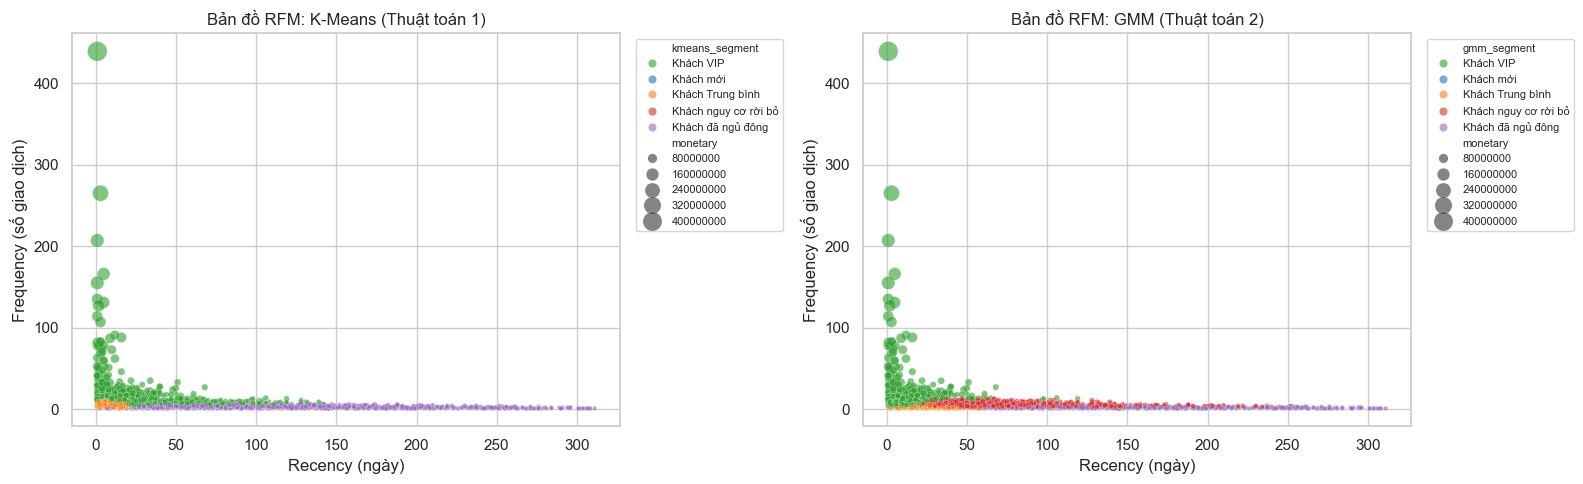

In [80]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import seaborn as sns

# Chuẩn bị dữ liệu và chạy mô hình (nếu chưa chạy trước đó)
X_rfm = np.log1p(rfm[["recency", "frequency", "monetary"]])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_rfm)

# 1. K-Means
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

# 2. GMM
gmm = GaussianMixture(n_components=5, random_state=42)
rfm["gmm_cluster"] = gmm.fit_predict(X_scaled)

# Sửa lại hàm ánh xạ (mapping) trực tiếp dựa trên đặc tính trung bình của cụm thay vì gán tĩnh 0-4
def auto_map_clusters(df, cluster_col):
    # Tính trung bình các chỉ số của từng cụm
    summary = df.groupby(cluster_col)[["recency", "frequency", "monetary"]].mean()
    
    mapping = {}
    for cluster_id in summary.index:
        r = summary.loc[cluster_id, "recency"]
        f = summary.loc[cluster_id, "frequency"]
        m = summary.loc[cluster_id, "monetary"]
        
        # Logic nhận diện dựa trên đặc trưng kinh doanh thực tế của cụm
        if f > summary["frequency"].quantile(0.7) and m > summary["monetary"].quantile(0.7):
            mapping[cluster_id] = "Khách VIP"
        elif r > summary["recency"].quantile(0.7) and f < summary["frequency"].quantile(0.4):
            mapping[cluster_id] = "Khách đã ngủ đông"
        elif r < summary["recency"].quantile(0.3) and f < summary["frequency"].quantile(0.4):
            mapping[cluster_id] = "Khách mới"
        elif r > summary["recency"].quantile(0.5) and (f >= summary["frequency"].quantile(0.4) or m >= summary["monetary"].quantile(0.4)):
            mapping[cluster_id] = "Khách nguy cơ rời bỏ"
        else:
            mapping[cluster_id] = "Khách Trung bình"
            
    return mapping

# Áp dụng hàm ánh xạ tự động động cho cả 2 mô hình để nhãn khớp đúng cụm dữ liệu
kmeans_mapping = auto_map_clusters(rfm, "kmeans_cluster")
rfm["kmeans_segment"] = rfm["kmeans_cluster"].map(kmeans_mapping)

gmm_mapping = auto_map_clusters(rfm, "gmm_cluster")
rfm["gmm_segment"] = rfm["gmm_cluster"].map(gmm_mapping)

# In lại bảng thống kê và vẽ biểu đồ với màu sắc đồng nhất
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sample_df = rfm.sample(min(len(rfm), 3000), random_state=0)

sns.scatterplot(data=sample_df, x="recency", y="frequency",
                hue="kmeans_segment", hue_order=segment_palette.keys(), palette=segment_palette,
                size="monetary", sizes=(10, 200), alpha=0.6, ax=axes[0])
axes[0].set_title("Bản đồ RFM: K-Means (Thuật toán 1)")
axes[0].set_xlabel("Recency (ngày)")
axes[0].set_ylabel("Frequency (số giao dịch)")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

sns.scatterplot(data=sample_df, x="recency", y="frequency",
                hue="gmm_segment", hue_order=segment_palette.keys(), palette=segment_palette,
                size="monetary", sizes=(10, 200), alpha=0.6, ax=axes[1])
axes[1].set_title("Bản đồ RFM: GMM (Thuật toán 2)")
axes[1].set_xlabel("Recency (ngày)")
axes[1].set_ylabel("Frequency (số giao dịch)")
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## 7.4. Đặc trưng hành vi bổ sung

RFM là xương sống nhưng chưa đủ. Bổ sung các đặc trưng tổng hợp mà mô hình churn rất "thích":

In [58]:
hanh_vi = (tx_ht.groupby("customer_id")
    .agg(gia_tri_don_tb=("amount", "mean"),
         so_nganh_hang=("category", "nunique"),
         ty_le_online=("channel", lambda s: s.eq("Online").mean()),
         ty_le_cuoi_tuan=("cuoi_tuan", "mean"),
         so_chi_nhanh=("branch", "nunique")))
# Tỷ lệ hoàn trả tính trên TOÀN BỘ giao dịch (kể cả HOAN_TRA)
hoan_tra = tx.groupby("customer_id")["status"].apply(
    lambda s: s.eq("HOAN_TRA").mean()).rename("ty_le_hoan_tra")
hanh_vi = hanh_vi.join(hoan_tra)
hanh_vi.head()

,gia_tri_don_tb,so_nganh_hang,ty_le_online,ty_le_cuoi_tuan,so_chi_nhanh,ty_le_hoan_tra
customer_id,,,,,,
C00001,"976,959.37",6,0.46,0.31,5,0.03
C00002,"962,195.92",6,0.45,0.24,5,0.04
C00003,"1,077,741.46",6,0.44,0.28,5,0.03
C00004,"1,052,217.67",6,0.41,0.30,5,0.04
C00005,"1,042,177.06",6,0.46,0.29,5,0.03


## 7.5. Ghép thành Feature Matrix và chuẩn hóa cho ML

Ba việc cuối: **(1)** ghép hồ sơ khácha hàng với RFM + hành vi (khách không có giao dịch nào được điền giá trị "trắng" hợp lý, kèm cờ `chua_tung_mua`); **(2)** mã hóa one-hot các biến phân loại; **(3)** chuẩn hóa `StandardScaler`.

In [59]:
#Ghép hồ sơ khách hàng với bảng RFM và các hành vi khác
#Mục tiêu: Gom tất cả thông tin lại về chung một bảng, đồng thời xử lý các khách hàng "vãng lai" (chưa từng mua hàng bao giờ) 
# bằng cách điền giá trị mặc định hợp lý và gắn cờ đánh dấu (chua_tung_mua)
# Lấy bảng thông tin hồ sơ khách hàng (kh) làm gốc, 
# sau đó nối (join) thêm bảng chỉ số RFM và bảng hành vi mua sắm vào

# 1. Ghép hồ sơ khách hàng gốc với bảng RFM và bảng hành vi dựa vào mã khách hàng (customer_id)
fm = (kh.set_index("customer_id")
        .join(rfm[["recency", "frequency", "monetary", "R", "F", "M", "phan_khuc"]])
        .join(hanh_vi))

# 2. Tạo cờ đánh dấu khách chưa từng mua hàng (dựa vào việc cột frequency bị trống NaN)
fm["chua_tung_mua"] = fm["frequency"].isna().astype(int)

# 3. Điền các giá trị trống (NaN) bằng các con số mặc định hợp lý
fm = fm.fillna({
    "recency": 999, "frequency": 0, "monetary": 0, 
    "R": 1, "F": 1, "M": 1, "phan_khuc": "Chưa mua", 
    "gia_tri_don_tb": 0, "so_nganh_hang": 0,
    "ty_le_online": 0, "ty_le_cuoi_tuan": 0, 
    "so_chi_nhanh": 0, "ty_le_hoan_tra": 0
})

# --- TRỰC QUAN HÓA OUTPUT ---
print("--- KẾT QUẢ PHẦN 1: BẢNG SAU KHI GHÉP VÀ ĐIỀN KHUYẾT ---")
print(f"Kích thước bảng hiện tại: {fm.shape[0]} dòng, {fm.shape[1]} cột")
fm.head()
#Không phải khách hàng nào trong file hồ sơ cũng phát sinh giao dịch. 
# Có những người đăng ký tài khoản nhưng chưa mua gì cả. Lệnh .fillna() giúp ta "lấp đầy" các ô trống của nhóm này bằng những con số an toàn 
# (như 0 hoặc 999) để mô hình máy tính không bị lỗi khi đọc dữ liệu.

--- KẾT QUẢ PHẦN 1: BẢNG SAU KHI GHÉP VÀ ĐIỀN KHUYẾT ---
Kích thước bảng hiện tại: 8000 dòng, 20 cột


,age,gender,city,tenure_months,support_tickets,churn,recency,frequency,monetary,R,F,M,phan_khuc,gia_tri_don_tb,so_nganh_hang,ty_le_online,ty_le_cuoi_tuan,so_chi_nhanh,ty_le_hoan_tra,chua_tung_mua
customer_id,,,,,,,,,,,,,,,,,,,,
C00001,47,Nữ,Hà Nội,15,1,0,1.00,643.00,"628,184,874.65",5.00,5.00,5.00,Khách VIP,"976,959.37",6.00,0.46,0.31,5.00,0.03,0
C00002,32,Nam,Đà Nẵng,20,2,0,1.00,439.00,"422,404,011.00",5.00,5.00,5.00,Khách VIP,"962,195.92",6.00,0.45,0.24,5.00,0.04,0
C00003,38,Nam,Cần Thơ,54,1,0,1.00,344.00,"370,743,062.76",5.00,5.00,5.00,Khách VIP,"1,077,741.46",6.00,0.44,0.28,5.00,0.03,0
C00004,60,Nam,TP HCM,37,2,0,1.00,306.00,"321,978,608.44",5.00,5.00,5.00,Khách VIP,"1,052,217.67",6.00,0.41,0.30,5.00,0.04,0
C00005,23,Nữ,TP HCM,39,0,0,3.00,265.00,"276,176,920.00",5.00,5.00,5.00,Khách VIP,"1,042,177.06",6.00,0.46,0.29,5.00,0.03,0


In [60]:
#Mã hóa One-hot các biến phân loại (Categorical Variables)
#Các thuật toán Machine Learning không hiểu các dữ liệu dạng chữ cái văn bản như giới tính (gender: Nam/Nữ), 
# thành phố (city), hay phân khúc khách hàng (phan_khuc).
# Ta dùng hàm pd.get_dummies để chuyển đổi các cột dạng chữ này thành các cột dạng số nhị phân (0 hoặc 1), gọi là kỹ thuật One-hot Encoding. 
# Chuyển đổi các cột phân loại dạng chữ thành các cột dạng số 0/1
fm = pd.get_dummies(fm, columns=["gender", "city", "phan_khuc"], dtype=int)

# --- TRỰC QUAN HÓA OUTPUT ---
print("--- KẾT QUẢ PHẦN 2: SAU KHI MÃ HÓA ONE-HOT ---")
print(f"Số lượng cột sau khi tách biến phân loại: {fm.shape[1]} cột")
# Xem thử một số cột mới sinh ra (ví dụ các cột bắt đầu bằng phan_khuc)
cot_phan_khuc = [c for c in fm.columns if "phan_khuc" in c]
fm[cot_phan_khuc].head()

--- KẾT QUẢ PHẦN 2: SAU KHI MÃ HÓA ONE-HOT ---
Số lượng cột sau khi tách biến phân loại: 30 cột


,phan_khuc_Chưa mua,phan_khuc_Khách VIP,phan_khuc_Khách mới,phan_khuc_Nguy cơ rời bỏ,phan_khuc_Trung bình,phan_khuc_Đã ngủ đông
customer_id,,,,,,
C00001,0,1,0,0,0,0
C00002,0,1,0,0,0,0
C00003,0,1,0,0,0,0
C00004,0,1,0,0,0,0
C00005,0,1,0,0,0,0


In [61]:
#Chuẩn hóa dữ liệu số bằng StandardScaler
# Các biến số trong bảng có biên độ rất khác nhau (ví dụ: tuổi từ 18 đến 60, trong khi tổng tiền monetary có thể lên tới vài chục triệu). 
# Nếu đưa thẳng vào mô hình, các biến có số lớn sẽ lấn át biến số nhỏ.
# Ta dùng StandardScaler để đưa toàn bộ các cột số về chung một mặt bằng phân phối chuẩn (có trung bình bằng 0 và độ lệch chuẩn bằng 1), 
# giúp mô hình học tập ổn định và tối ưu hóa tốt hơn. 
from sklearn.preprocessing import StandardScaler

# Khai báo danh sách các cột dạng số cần chuẩn hóa
cot_so = [
    "age", "tenure_months", "support_tickets", "recency", "frequency",
    "monetary", "gia_tri_don_tb", "so_nganh_hang", "ty_le_online",
    "ty_le_cuoi_tuan", "so_chi_nhanh", "ty_le_hoan_tra"
]

# Thực hiện chuẩn hóa các cột số trên
fm[cot_so] = StandardScaler().fit_transform(fm[cot_so])

# Lưu bảng Feature Matrix hoàn chỉnh xuống ổ cứng
fm.to_parquet(PROCESSED / "feature_matrix.parquet")

# --- TRỰC QUAN HÓA OUTPUT ---
print("--- KẾT QUẢ PHẦN 3: HOÀN THIỆN FEATURE MATRIX ---")
print(f"Feature Matrix cuối cùng: {fm.shape[0]:,} khách hàng x {fm.shape[1]} cột (nhãn: churn)")
fm[cot_so].head()

--- KẾT QUẢ PHẦN 3: HOÀN THIỆN FEATURE MATRIX ---
Feature Matrix cuối cùng: 8,000 khách hàng x 30 cột (nhãn: churn)


,age,tenure_months,support_tickets,recency,frequency,monetary,gia_tri_don_tb,so_nganh_hang,ty_le_online,ty_le_cuoi_tuan,so_chi_nhanh,ty_le_hoan_tra
customer_id,,,,,,,,,,,,
C00001,0.18,-0.88,-0.19,-0.55,43.79,41.04,-0.08,1.76,0.07,0.15,1.57,0.00
C00002,-0.80,-0.60,0.74,-0.55,29.74,27.43,-0.10,1.76,0.00,-0.15,1.57,0.03
C00003,-0.40,1.37,-0.19,-0.55,23.19,24.02,0.05,1.76,-0.03,0.00,1.57,0.01
C00004,1.03,0.39,0.74,-0.55,20.58,20.79,0.02,1.76,-0.13,0.11,1.57,0.06
C00005,-1.38,0.51,-1.12,-0.54,17.75,17.76,0.01,1.76,0.07,0.05,1.57,-0.08


In [62]:
# from sklearn.preprocessing import StandardScaler

# fm = (kh.set_index("customer_id")
#         .join(rfm[["recency", "frequency", "monetary", "R", "F", "M", "phan_khuc"]])
#         .join(hanh_vi))
# fm["chua_tung_mua"] = fm["frequency"].isna().astype(int)
# fm = fm.fillna({"recency": 999, "frequency": 0, "monetary": 0, "R": 1, "F": 1, "M": 1,
#                 "phan_khuc": "Chưa mua", "gia_tri_don_tb": 0, "so_nganh_hang": 0,
#                 "ty_le_online": 0, "ty_le_cuoi_tuan": 0, "so_chi_nhanh": 0,
#                 "ty_le_hoan_tra": 0})

# # One-hot cho biến phân loại
# fm = pd.get_dummies(fm, columns=["gender", "city", "phan_khuc"], dtype=int)

# # Chuẩn hóa các cột số (trừ nhãn churn và các cột nhị phân)
# cot_so = ["age", "tenure_months", "support_tickets", "recency", "frequency",
#           "monetary", "gia_tri_don_tb", "so_nganh_hang", "ty_le_online",
#           "ty_le_cuoi_tuan", "so_chi_nhanh", "ty_le_hoan_tra"]
# fm[cot_so] = StandardScaler().fit_transform(fm[cot_so])

# fm.to_parquet(PROCESSED / "feature_matrix.parquet")
# print(f"Feature Matrix: {fm.shape[0]:,} khách hàng x {fm.shape[1]} cột (nhãn: churn)")
fm.head()

,age,tenure_months,support_tickets,churn,recency,frequency,monetary,R,F,M,...,city_Hà Nội,city_Hải Phòng,city_TP HCM,city_Đà Nẵng,phan_khuc_Chưa mua,phan_khuc_Khách VIP,phan_khuc_Khách mới,phan_khuc_Nguy cơ rời bỏ,phan_khuc_Trung bình,phan_khuc_Đã ngủ đông
customer_id,,,,,,,,,,,,,,,,,,,,,
C00001,0.18,-0.88,-0.19,0,-0.55,43.79,41.04,5.00,5.00,5.00,...,1,0,0,0,0,1,0,0,0,0
C00002,-0.80,-0.60,0.74,0,-0.55,29.74,27.43,5.00,5.00,5.00,...,0,0,0,1,0,1,0,0,0,0
C00003,-0.40,1.37,-0.19,0,-0.55,23.19,24.02,5.00,5.00,5.00,...,0,0,0,0,0,1,0,0,0,0
C00004,1.03,0.39,0.74,0,-0.55,20.58,20.79,5.00,5.00,5.00,...,0,0,1,0,0,1,0,0,0,0
C00005,-1.38,0.51,-1.12,0,-0.54,17.75,17.76,5.00,5.00,5.00,...,0,0,1,0,0,1,0,0,0,0


**Kiểm chứng "sẵn sàng cho ML":** huấn luyện nhanh một mô hình Logistic Regression — nếu pipeline đặc trưng tốt, mô hình phải vượt xa mức đoán mò (AUC = 0.5):

In [63]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

X = fm.drop(columns="churn"); y = fm["churn"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25,
                                          random_state=42, stratify=y)
mo_hinh = LogisticRegression(max_iter=1000).fit(X_tr, y_tr)
auc = roc_auc_score(y_te, mo_hinh.predict_proba(X_te)[:, 1])
print(f"AUC trên tập kiểm tra: {auc:.3f}  (đoán mò = 0.500)")

anh_huong = pd.Series(mo_hinh.coef_[0], index=X.columns)
anh_huong.reindex(anh_huong.abs().sort_values(ascending=False).index).head(8) \
    .rename("hệ số (>0 đẩy churn, <0 giữ chân)").to_frame()

AUC trên tập kiểm tra: 0.748  (đoán mò = 0.500)


,"hệ số (>0 đẩy churn, <0 giữ chân)"
frequency,-2.88
tenure_months,-0.52
support_tickets,0.49
phan_khuc_Khách VIP,-0.27
gender_Nam,-0.23
gender_Nữ,-0.23
phan_khuc_Nguy cơ rời bỏ,-0.22
city_Hà Nội,-0.16


---
# BÀI TẬP VỀ NHÀ

Làm trực tiếp vào các cell trống bên dưới. Nộp notebook đã chạy đầy đủ output.

#### Bài tập 1 (RFM): Tính bảng RFM riêng cho từng `channel` (Online và Cửa hàng). Phân khúc "Khách VIP" ở hai kênh khác nhau thế nào về Monetary trung bình?

In [64]:
# --- BÀI TẬP 1 ---


#### Bài tập 2 (Feature): Thêm đặc trưng `so_ngay_giua_2_lan_mua_tb` (khoảng cách trung bình giữa hai lần mua liên tiếp của mỗi khách, tính bằng ngày; khách mua 1 lần điền 999). Gợi ý: `groupby().ts.apply(lambda s: s.sort_values().diff().dt.days.mean())`.

In [65]:
# --- BÀI TẬP 2 ---
